# Exploratory Data Analysis

Loading the dataset and checking its properties.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load datasets
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

# Assign labels (1 for Fake, 0 for True)
fake_df['label'] = 1
true_df['label'] = 0

# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save combined raw data
df.to_csv('../data/raw.csv', index=False)
df.head()


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## Class Distribution

Let's see how balanced the dataset is.

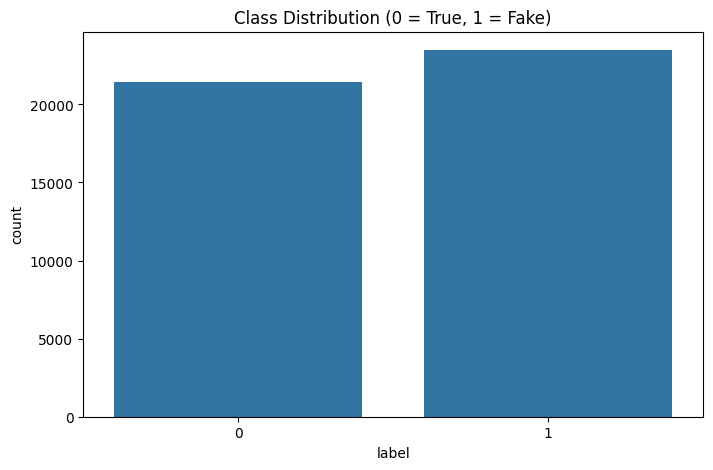

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label')
plt.title('Class Distribution (0 = True, 1 = Fake)')
plt.show()


## Text Length Distribution

Comparing the length of fake vs true news articles.

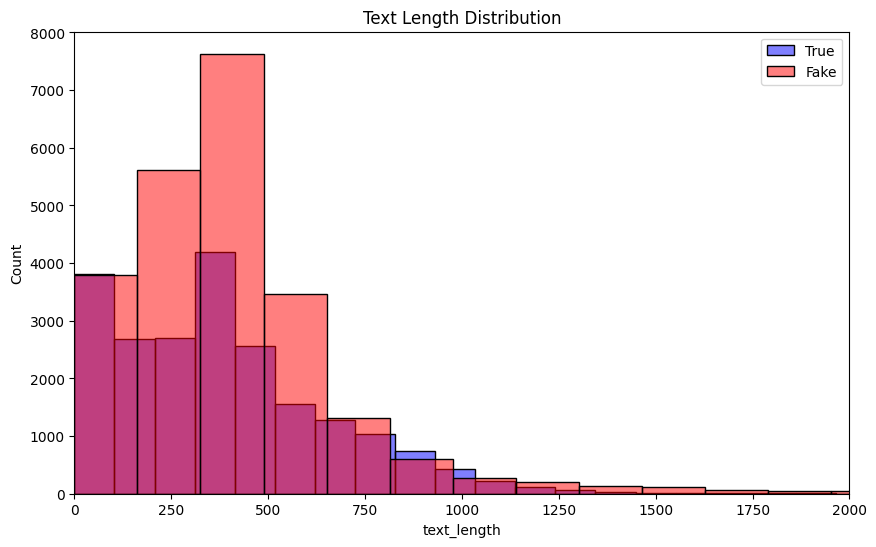

In [3]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df[df['label'] == 0]['text_length'], color='blue', label='True', bins=50, alpha=0.5)
sns.histplot(df[df['label'] == 1]['text_length'], color='red', label='Fake', bins=50, alpha=0.5)
plt.xlim(0, 2000) # limit to 2000 words for better visualization
plt.title('Text Length Distribution')
plt.legend()
plt.show()


## Word Clouds

Most frequent words in True vs Fake news.

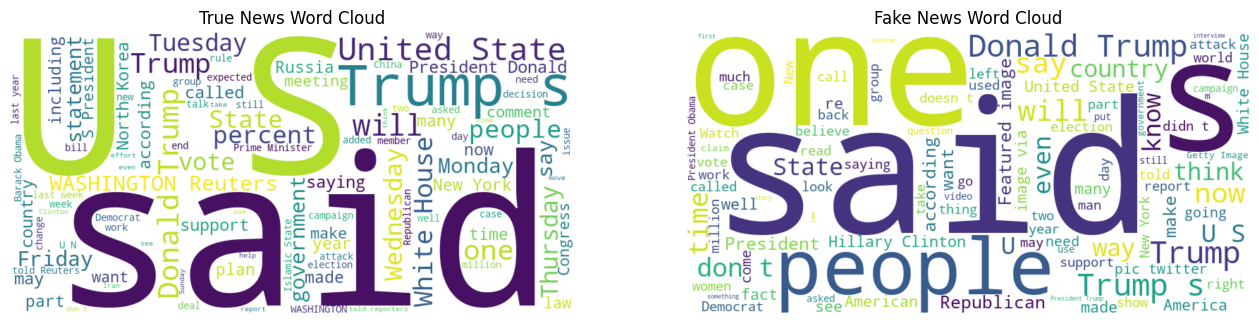

In [4]:
true_text = " ".join(df[df['label'] == 0]['text'].astype(str))
fake_text = " ".join(df[df['label'] == 1]['text'].astype(str))

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
wc_true = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(true_text)
plt.imshow(wc_true, interpolation='bilinear')
plt.title('True News Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
wc_fake = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(fake_text)
plt.imshow(wc_fake, interpolation='bilinear')
plt.title('Fake News Word Cloud')
plt.axis('off')

plt.show()
